# Final Consolidation, ML Evaluation & Reporting

In [ ]:
# Install compatible dependencies

import sys
import subprocess

subprocess.run(
    [
        sys.executable, "-m", "pip", "install", "-q",
        "--force-reinstall",
        "numpy==2.2.6",
        "scipy==1.15.3",
        "scikit-learn==1.6.1",
        "pandas==2.2.3",
        "pyarrow==18.1.0",
        "matplotlib==3.10.0",
        "seaborn==0.13.2",
        "kaggle"
    ],
    check=True
)

print("Pinned dependencies installed.")
print("IMPORTANT: Restart the Colab runtime now.")
print("Runtime -> Restart session")

Pinned dependencies installed.
IMPORTANT: Restart the Colab runtime now.
Runtime -> Restart session


In [ ]:
# Imports

import os
import sys
from pathlib import Path
import shutil
import json
import warnings
import subprocess

import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score
)

warnings.filterwarnings("ignore")

import scipy
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)

NumPy: 2.2.6
Pandas: 2.2.3
SciPy: 1.15.3
scikit-learn: 1.6.1


In [ ]:
# Kaggle authentication + workspace

try:
    from google.colab import userdata
    token = userdata.get("KAGGLE_API_TOKEN")
except Exception:
    token = None

if not token:
    raise RuntimeError(
        "Add a Colab Secret named KAGGLE_API_TOKEN containing "
        "your current Kaggle API token."
    )

os.environ["KAGGLE_API_TOKEN"] = token

BASE = Path("/content/final_cic_project")
RAW = BASE / "raw"
OUT = BASE / "results"
DATASET_RESULTS = OUT / "dashboard_data"
ML_OUT = OUT / "ml"

for p in [RAW, OUT, DATASET_RESULTS, ML_OUT]:
    p.mkdir(parents=True, exist_ok=True)

print("Workspace:", BASE)
print("Raw:", RAW)
print("Results:", OUT)

Workspace: /content/final_cic_project
Raw: /content/final_cic_project/raw
Results: /content/final_cic_project/results


In [ ]:
# Dataset definitions

DATASETS = {
    "CIC-IDS2017": "dhoogla/cicids2017",
    "CIC-IDS2018": "solarmainframe/ids-intrusion-csv",
    "CIC-DDoS2019": "dhoogla/cicddos2019",
}

def dataset_root(name):
    return RAW / name.lower().replace("-", "_")

def data_files(root):
    files = list(root.rglob("*.csv")) + list(root.rglob("*.parquet"))
    return sorted(files)

def row_count(path):
    if path.suffix.lower() == ".parquet":
        return pq.ParquetFile(path).metadata.num_rows
    return sum(1 for _ in open(path, "rb")) - 1

def columns_for(path):
    if path.suffix.lower() == ".parquet":
        return pq.read_schema(path).names
    return pd.read_csv(path, nrows=0).columns.tolist()

def read_data(path, columns=None):
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path, columns=columns)
    return pd.read_csv(path, usecols=columns, low_memory=False)

def label_column(columns):
    candidates = [
        "Label", "label", " Label", " Label ",
        "Attack", "attack", "Class", "class"
    ]
    for c in candidates:
        if c in columns:
            return c
    # Prefer a string-like final column for CIC-style datasets.
    return columns[-1]

print("Helper functions ready.")

Helper functions ready.


In [ ]:
# Download datasets

for name, dataset_id in DATASETS.items():
    target = dataset_root(name)

    existing = data_files(target)

    if existing:
        print(f"{name}: already present ({len(existing)} data files)")
        continue

    target.mkdir(parents=True, exist_ok=True)

    print(f"Downloading {name}: {dataset_id}")

    subprocess.run(
        [
            sys.executable, "-m", "kaggle",
            "datasets", "download",
            "-d", dataset_id,
            "-p", str(target),
            "--unzip"
        ],
        check=True
    )

    existing = data_files(target)
    print(f"  downloaded data files: {len(existing)}")

print("Dataset download stage complete.")

CIC-IDS2017: already present (8 data files)
CIC-IDS2018: already present (10 data files)
CIC-DDoS2019: already present (17 data files)
Dataset download stage complete.


In [ ]:
# Source inventory

inventory_rows = []

for name in DATASETS:
    root = dataset_root(name)
    files = data_files(root)

    for f in files:
        cols = columns_for(f)
        inventory_rows.append({
            "dataset": name,
            "file": f.name,
            "format": f.suffix.lower().replace(".", ""),
            "records": row_count(f),
            "columns": len(cols),
            "size_mb": round(f.stat().st_size / (1024**2), 3)
        })

inventory = pd.DataFrame(inventory_rows)

if inventory.empty:
    raise RuntimeError("No CSV or Parquet files were found after download.")

dataset_overview = (
    inventory
    .groupby("dataset", as_index=False)
    .agg(
        source_files=("file", "count"),
        total_records=("records", "sum"),
        max_columns=("columns", "max"),
        total_size_mb=("size_mb", "sum")
    )
)

inventory.to_csv(DATASET_RESULTS / "dataset_source_inventory.csv", index=False)
dataset_overview.to_csv(DATASET_RESULTS / "dataset_overview.csv", index=False)

display(dataset_overview)
display(inventory)

,dataset,source_files,total_records,max_columns,total_size_mb
0,CIC-DDoS2019,17,431371,78,33.602
1,CIC-IDS2017,8,2313810,78,258.116
2,CIC-IDS2018,10,16233002,84,6567.620


,dataset,file,format,records,columns,size_mb
0,CIC-IDS2017,Benign-Monday-no-metadata.parquet,parquet,458831,78,54.136
1,CIC-IDS2017,Botnet-Friday-no-metadata.parquet,parquet,176038,78,18.935
2,CIC-IDS2017,Bruteforce-Tuesday-no-metadata.parquet,parquet,389714,78,44.003
3,CIC-IDS2017,DDoS-Friday-no-metadata.parquet,parquet,221264,78,24.130
4,CIC-IDS2017,DoS-Wednesday-no-metadata.parquet,parquet,584991,78,65.039
5,CIC-IDS2017,Infiltration-Thursday-no-metadata.parquet,parquet,207630,78,22.074
6,CIC-IDS2017,Portscan-Friday-no-metadata.parquet,parquet,119522,78,12.964
7,CIC-IDS2017,WebAttacks-Thursday-no-metadata.parquet,parquet,155820,78,16.835
8,CIC-IDS2018,02-14-2018.csv,csv,1048575,80,341.628
9,CIC-IDS2018,02-15-2018.csv,csv,1048575,80,358.530


## 7. Cross-dataset quality analysis

The quality scan below is intentionally compact. It examines each source file independently and aggregates missing values, infinities, duplicate rows, numeric columns, and constant numeric features.

For very large CSV files this can take time because the files must be read.

In [ ]:
# Cross-dataset quality analysis

import gc
import pyarrow as pa
import pyarrow.parquet as pq

quality_rows = []

BATCH_SIZE = 100_000

# Helper: PyArrow numeric type

def is_numeric_arrow_type(dtype):
    return (
        pa.types.is_integer(dtype)
        or pa.types.is_floating(dtype)
        or pa.types.is_decimal(dtype)
    )


# Helper: safely count numeric infinities

def count_infinite_safe(series):
    """
    Safely count +/- infinity in a possibly mixed-type Series.
    Non-numeric values are ignored.
    """
    numeric = pd.to_numeric(
        series,
        errors="coerce"
    )

    return int(
        np.isinf(
            numeric.to_numpy(dtype=np.float64)
        ).sum()
    )


# Helper: safely update min/max

def update_numeric_stats(series, stat):

    numeric = pd.to_numeric(
        series,
        errors="coerce"
    )

    valid = numeric.dropna()

    if len(valid) == 0:
        return

    batch_min = valid.min()
    batch_max = valid.max()

    if stat["min"] is None:

        stat["min"] = batch_min
        stat["max"] = batch_max

    else:

        stat["min"] = min(
            stat["min"],
            batch_min
        )

        stat["max"] = max(
            stat["max"],
            batch_max
        )

    stat["non_null"] += len(valid)


# Process datasets

for name in DATASETS:

    root = dataset_root(name)

    for f in data_files(root):

        print(
            f"\nAnalyzing: {name} / {f.name}"
        )

        # PARQUET

        if f.suffix.lower() == ".parquet":

            pf = pq.ParquetFile(f)

            records = pf.metadata.num_rows
            columns = len(
                pf.schema_arrow.names
            )

            missing_values = 0
            infinite_values = 0

            schema = pf.schema_arrow

            numeric_columns = [
                field.name
                for field in schema
                if is_numeric_arrow_type(
                    field.type
                )
            ]

            stats = {
                c: {
                    "min": None,
                    "max": None,
                    "non_null": 0
                }
                for c in numeric_columns
            }

            # Process Parquet batches

            for batch in pf.iter_batches(
                batch_size=BATCH_SIZE
            ):

                df = batch.to_pandas()

                # Missing values
                missing_values += int(
                    df.isna().sum().sum()
                )

                # Numeric analysis
                for c in numeric_columns:

                    series = df[c]

                    infinite_values += (
                        count_infinite_safe(
                            series
                        )
                    )

                    update_numeric_stats(
                        series,
                        stats[c]
                    )

                del df
                del batch

                gc.collect()

            constant_numeric = sum(
                1
                for s in stats.values()
                if s["non_null"] > 0
                and s["min"] == s["max"]
            )

            # Global duplicate detection is intentionally
            # omitted because it would require large memory.
            duplicate_occurrences = np.nan

        # CSV

        else:

            records = 0
            columns = None

            missing_values = 0
            infinite_values = 0

            numeric_columns = None
            stats = {}

            # Read CSV in chunks

            for chunk in pd.read_csv(
                f,
                chunksize=BATCH_SIZE,
                low_memory=False
            ):

                # Determine schema from first chunk
                if columns is None:

                    columns = len(
                        chunk.columns
                    )

                    label_candidates = [
                        c for c in chunk.columns
                        if c.strip().lower()
                        in {
                            "label",
                            "class",
                            "attack",
                            "attack_type"
                        }
                    ]

                    numeric_columns = [
                        c for c in chunk.columns
                        if c not in label_candidates
                    ]

                    stats = {
                        c: {
                            "min": None,
                            "max": None,
                            "non_null": 0
                        }
                        for c in numeric_columns
                    }

                records += len(chunk)

                # Missing values

                missing_values += int(
                    chunk.isna().sum().sum()
                )

                # Numeric analysis

                for c in numeric_columns:

                    series = chunk[c]

                    infinite_values += (
                        count_infinite_safe(
                            series
                        )
                    )

                    update_numeric_stats(
                        series,
                        stats[c]
                    )

                del chunk

                gc.collect()

            constant_numeric = sum(
                1
                for s in stats.values()
                if s["non_null"] > 0
                and s["min"] == s["max"]
            )

            duplicate_occurrences = np.nan

        # Save file-level result

        quality_rows.append({

            "dataset":
                name,

            "file":
                f.name,

            "records":
                int(records),

            "columns":
                int(columns),

            "missing_values":
                int(missing_values),

            "infinite_values":
                int(infinite_values),

            "duplicate_occurrences":
                duplicate_occurrences,

            "constant_numeric_features":
                int(constant_numeric)
        })

        gc.collect()

        print(
            f"  records      = {records:,}\n"
            f"  columns      = {columns:,}\n"
            f"  missing      = {missing_values:,}\n"
            f"  infinite     = {infinite_values:,}\n"
            f"  constants    = {constant_numeric:,}"
        )


# Build dataset-level summary

quality_file = pd.DataFrame(
    quality_rows
)


quality_summary = (
    quality_file
    .groupby(
        "dataset",
        as_index=False
    )
    .agg(
        records=(
            "records",
            "sum"
        ),

        files=(
            "file",
            "count"
        ),

        missing_values=(
            "missing_values",
            "sum"
        ),

        infinite_values=(
            "infinite_values",
            "sum"
        ),

        duplicate_occurrences=(
            "duplicate_occurrences",
            "sum"
        ),

        max_constant_numeric_features=(
            "constant_numeric_features",
            "max"
        )
    )
)


# Save results

quality_file.to_csv(
    DATASET_RESULTS /
    "quality_by_source_file.csv",
    index=False
)

quality_summary.to_csv(
    DATASET_RESULTS /
    "quality_summary.csv",
    index=False
)


display(
    quality_summary
)


Analyzing: CIC-IDS2017 / Benign-Monday-no-metadata.parquet
  records      = 458,831
  columns      = 78
  missing      = 0
  infinite     = 0
  constants    = 10

Analyzing: CIC-IDS2017 / Botnet-Friday-no-metadata.parquet
  records      = 176,038
  columns      = 78
  missing      = 0
  infinite     = 0
  constants    = 10

Analyzing: CIC-IDS2017 / Bruteforce-Tuesday-no-metadata.parquet
  records      = 389,714
  columns      = 78
  missing      = 0
  infinite     = 0
  constants    = 10

Analyzing: CIC-IDS2017 / DDoS-Friday-no-metadata.parquet
  records      = 221,264
  columns      = 78
  missing      = 0
  infinite     = 0
  constants    = 10

Analyzing: CIC-IDS2017 / DoS-Wednesday-no-metadata.parquet
  records      = 584,991
  columns      = 78
  missing      = 0
  infinite     = 0
  constants    = 10

Analyzing: CIC-IDS2017 / Infiltration-Thursday-no-metadata.parquet
  records      = 207,630
  columns      = 78
  missing      = 0
  infinite     = 0
  constants    = 8

Analyzing: 

,dataset,records,files,missing_values,infinite_values,duplicate_occurrences,max_constant_numeric_features
0,CIC-DDoS2019,431371,17,0,0,0.0,14
1,CIC-IDS2017,2313810,8,0,0,0.0,10
2,CIC-IDS2018,16233002,10,59721,131799,0.0,10


## 8. Class distribution

Labels are detected from common CIC-style label names. The output contains both dataset-level counts and percentages.

In [ ]:
# Class distribution — RAM-SAFE STREAMING VERSION

import gc
from collections import Counter

class_rows = []

BATCH_SIZE = 100_000


for name in DATASETS:

    root = dataset_root(name)

    for f in data_files(root):

        print(f"\nCounting classes: {name} / {f.name}")

        cols = columns_for(f)
        label_col = label_column(cols)

        counter = Counter()

        # PARQUET

        if f.suffix.lower() == ".parquet":

            pf = pq.ParquetFile(f)

            # Read ONLY the label column, in batches.
            for batch in pf.iter_batches(
                batch_size=BATCH_SIZE,
                columns=[label_col]
            ):

                labels = batch.column(0).to_pylist()

                counter.update(
                    str(x) for x in labels
                )

                del labels
                del batch

            del pf

        # CSV

        else:

            for chunk in pd.read_csv(
                f,
                usecols=[label_col],
                chunksize=BATCH_SIZE,
                low_memory=False
            ):

                # Convert only this 100k-row label chunk
                # to strings before counting.
                counter.update(
                    chunk[label_col]
                    .astype(str)
                    .tolist()
                )

                del chunk

                gc.collect()

        # Save file-level counts

        for label, count in counter.items():

            class_rows.append({
                "dataset": name,
                "file": f.name,
                "label": label,
                "count": int(count)
            })

        print(
            f"  classes found = {len(counter)}"
        )
        print(
            f"  records       = {sum(counter.values()):,}"
        )

        del counter

        gc.collect()


# Build DataFrames

class_file = pd.DataFrame(
    class_rows
)


class_summary = (
    class_file
    .groupby(
        ["dataset", "label"],
        as_index=False
    )["count"]
    .sum()
)


# Percentages

class_summary["percentage"] = (
    class_summary["count"]
    /
    class_summary
    .groupby("dataset")["count"]
    .transform("sum")
    * 100
)


# Save results

class_file.to_csv(
    DATASET_RESULTS /
    "class_distribution_by_file.csv",
    index=False
)

class_summary.to_csv(
    DATASET_RESULTS /
    "class_distribution.csv",
    index=False
)


# Display

display(
    class_summary.sort_values(
        ["dataset", "count"],
        ascending=[True, False]
    )
)


gc.collect()


Counting classes: CIC-IDS2017 / Benign-Monday-no-metadata.parquet
  classes found = 1
  records       = 458,831

Counting classes: CIC-IDS2017 / Botnet-Friday-no-metadata.parquet
  classes found = 2
  records       = 176,038

Counting classes: CIC-IDS2017 / Bruteforce-Tuesday-no-metadata.parquet
  classes found = 3
  records       = 389,714

Counting classes: CIC-IDS2017 / DDoS-Friday-no-metadata.parquet
  classes found = 2
  records       = 221,264

Counting classes: CIC-IDS2017 / DoS-Wednesday-no-metadata.parquet
  classes found = 6
  records       = 584,991

Counting classes: CIC-IDS2017 / Infiltration-Thursday-no-metadata.parquet
  classes found = 2
  records       = 207,630

Counting classes: CIC-IDS2017 / Portscan-Friday-no-metadata.parquet
  classes found = 2
  records       = 119,522

Counting classes: CIC-IDS2017 / WebAttacks-Thursday-no-metadata.parquet
  classes found = 4
  records       = 155,820

Counting classes: CIC-IDS2018 / 02-14-2018.csv
  classes found = 3
  records

,dataset,label,count,percentage
4,CIC-DDoS2019,DrDoS_NTP,121368,28.135410
13,CIC-DDoS2019,TFTP,98917,22.930841
0,CIC-DDoS2019,Benign,97831,22.679086
12,CIC-DDoS2019,Syn,49373,11.445600
14,CIC-DDoS2019,UDP,18090,4.193606
7,CIC-DDoS2019,DrDoS_UDP,10420,2.415554
15,CIC-DDoS2019,UDP-lag,8872,2.056698
9,CIC-DDoS2019,MSSQL,8523,1.975793
3,CIC-DDoS2019,DrDoS_MSSQL,6212,1.440060
1,CIC-DDoS2019,DrDoS_DNS,3669,0.850544


0

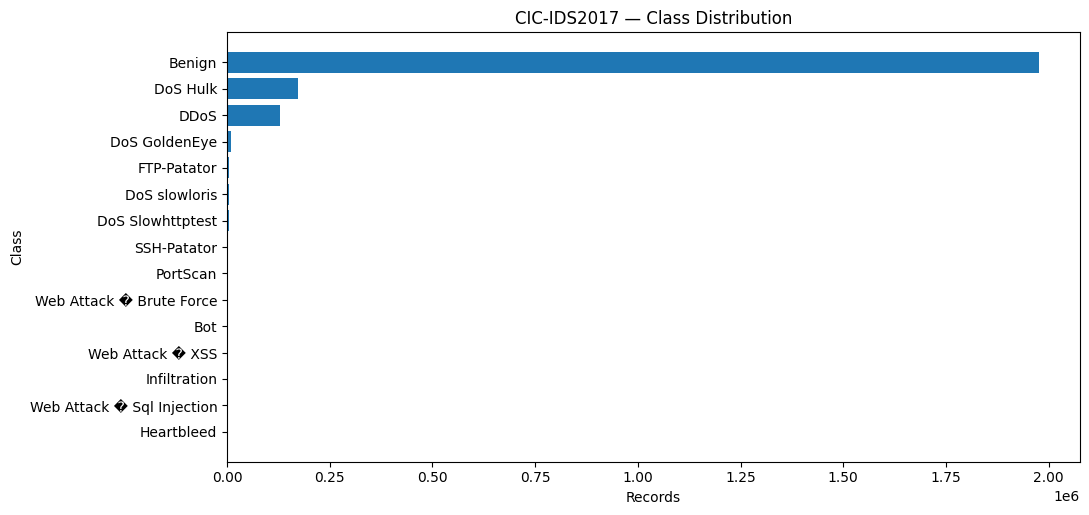

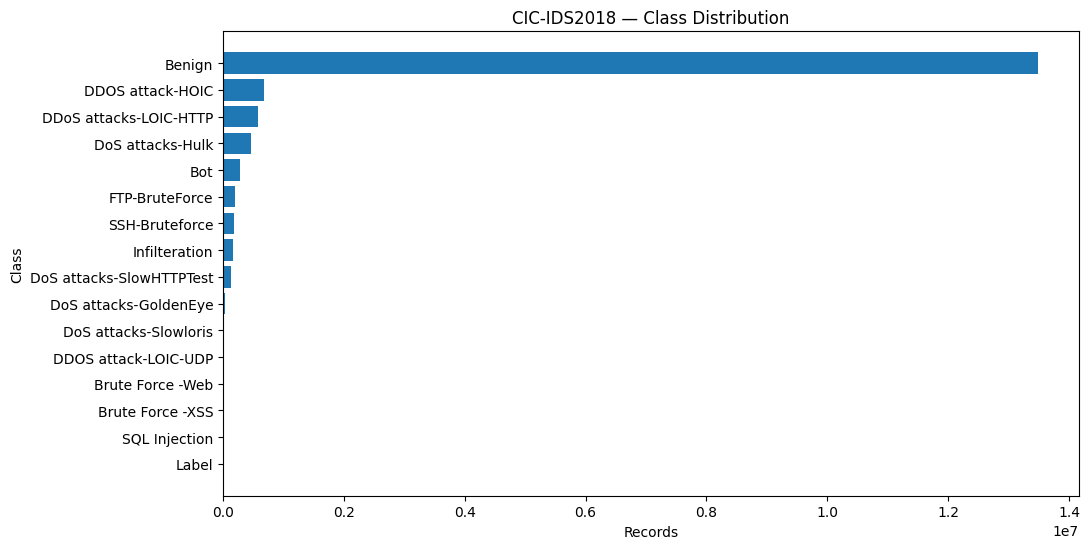

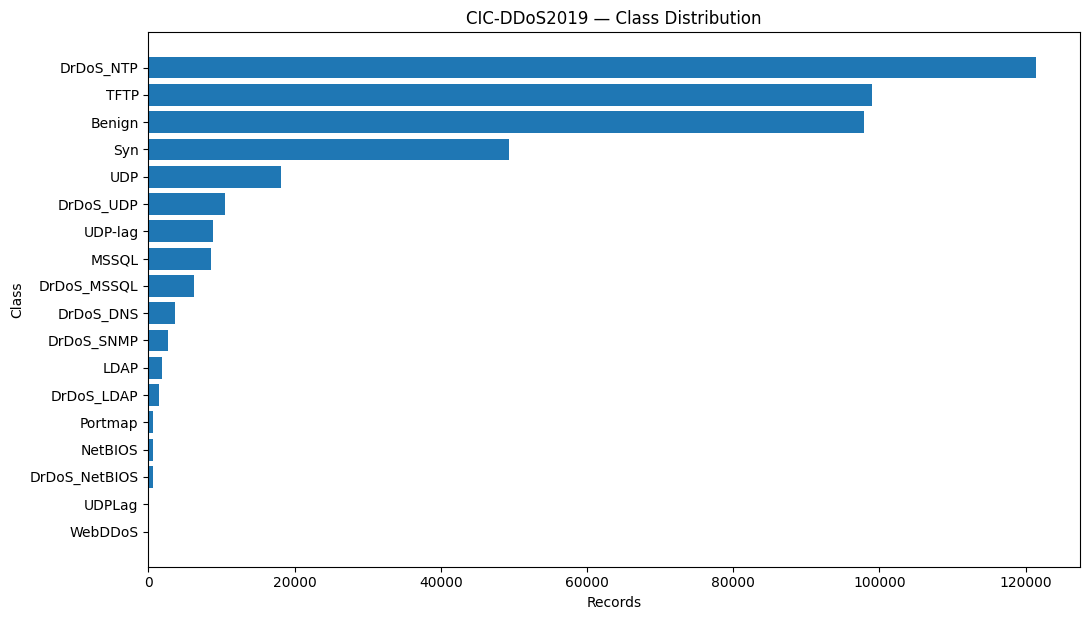

In [ ]:
# Class-distribution plots

for dataset in DATASETS:
    tmp = class_summary[class_summary["dataset"] == dataset].copy()
    tmp = tmp.sort_values("count", ascending=True)

    plt.figure(figsize=(11, max(5, 0.35 * len(tmp))))
    plt.barh(tmp["label"], tmp["count"])
    plt.title(f"{dataset} — Class Distribution")
    plt.xlabel("Records")
    plt.ylabel("Class")
    plt.tight_layout()

    safe = dataset.lower().replace("-", "_")
    plt.savefig(
        DATASET_RESULTS / f"{safe}_class_distribution.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

## 10. Final dataset-selection decision

The decision recorded here follows the project's completed comparative analysis:

- **CIC-IDS2017 — Primary dataset**
- **CIC-IDS2018 — Secondary benchmark**
- **CIC-DDoS2019 — Specialized DDoS benchmark**

CIC-DDoS2019 is therefore included in the comparison without displacing the general-purpose primary dataset.

In [ ]:
# Final dataset-selection decision
selection = pd.DataFrame([
    {
        "dataset": "CIC-IDS2017",
        "role": "Primary",
        "decision": "Selected",
        "reason": (
            "Best fit for the main general-purpose ML IDS experiment "
            "within the project's comparative analysis."
        )
    },
    {
        "dataset": "CIC-IDS2018",
        "role": "Secondary",
        "decision": "Retained",
        "reason": (
            "Useful larger-scale benchmark and comparative reference "
            "for the primary experiment."
        )
    },
    {
        "dataset": "CIC-DDoS2019",
        "role": "Specialized",
        "decision": "Retained",
        "reason": (
            "Useful for DDoS-focused evaluation but too specialized "
            "to replace the primary general-purpose dataset."
        )
    }
])

selection.to_csv(DATASET_RESULTS / "final_dataset_selection.csv", index=False)
display(selection)

,dataset,role,decision,reason
0,CIC-IDS2017,Primary,Selected,Best fit for the main general-purpose ML IDS e...
1,CIC-IDS2018,Secondary,Retained,Useful larger-scale benchmark and comparative ...
2,CIC-DDoS2019,Specialized,Retained,Useful for DDoS-focused evaluation but too spe...


## 11. Final CIC-IDS2017 Random Forest baseline

This is an **independent final baseline** rather than a deployment-ready training run.

To keep Colab execution practical, the notebook uses at most **1,000,000 CIC-IDS2017 rows**, sampled with a fixed random seed. The split is stratified where possible.

Model:
- Random Forest
- 100 trees
- `class_weight="balanced_subsample"`
- `max_features="sqrt"`

In [ ]:
# Load CIC-IDS2017 for final ML baseline

primary_root = dataset_root("CIC-IDS2017")
primary_files = data_files(primary_root)

if not primary_files:
    raise RuntimeError("No CIC-IDS2017 source files found.")

frames = []

for f in primary_files:
    cols = columns_for(f)
    label_col = label_column(cols)

    df = read_data(f)

    if label_col not in df.columns:
        # Fallback to a case-insensitive label lookup.
        matches = [c for c in df.columns if c.lower().strip() == "label"]
        if matches:
            label_col = matches[0]
        else:
            raise RuntimeError(f"Could not identify label column in {f.name}")

    frames.append(df)

primary = pd.concat(frames, ignore_index=True)

print("CIC-IDS2017 combined shape:", primary.shape)
print("Label column:", label_col)

CIC-IDS2017 combined shape: (2313810, 78)
Label column: Label


In [ ]:
# Prepare ML sample

df_ml = primary.copy()

# Normalize infinities to missing values.
df_ml.replace([np.inf, -np.inf], np.nan, inplace=True)

y = df_ml[label_col].astype(str)

X = df_ml.drop(columns=[label_col]).copy()

# Keep numeric features only for this baseline.
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X = X[numeric_cols]

# Replace remaining missing values with training-independent medians.
# Medians are saved so the exact baseline transformation is reproducible.
medians = X.median(numeric_only=True)
X = X.fillna(medians)

# Remove constant columns.
constant_features = [
    c for c in X.columns
    if X[c].nunique(dropna=False) <= 1
]

if constant_features:
    X = X.drop(columns=constant_features)

MAX_ROWS = 1_000_000
RANDOM_STATE = 42

if len(X) > MAX_ROWS:
    # Stratified sample keeps rare classes represented where possible.
    try:
        X_sample, _, y_sample, _ = train_test_split(
            X,
            y,
            train_size=MAX_ROWS,
            stratify=y,
            random_state=RANDOM_STATE
        )
        X = X_sample
        y = y_sample
    except ValueError:
        X, _, y, _ = train_test_split(
            X,
            y,
            train_size=MAX_ROWS,
            random_state=RANDOM_STATE
        )

print("ML sample shape:", X.shape)
print("Number of classes:", y.nunique())
print("Features used:", len(X.columns))
print("Constant features removed:", len(constant_features))

ML sample shape: (1000000, 69)
Number of classes: 15
Features used: 69
Constant features removed: 8


In [ ]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (800000, 69)
Test : (200000, 69)


In [ ]:
# Train Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced_subsample",
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Balanced accuracy:", balanced_accuracy)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Accuracy: 0.998365
Balanced accuracy: 0.8164545262638166
Macro F1: 0.8332781522250925
Weighted F1: 0.998326008258817


In [ ]:
# ML metrics and confusion matrix

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=rf.classes_,
    zero_division=0
)

per_class = pd.DataFrame({
    "class": rf.classes_,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

metrics = pd.DataFrame([{
    "model": "RandomForest",
    "sample_rows": len(X),
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "features": X.shape[1],
    "classes": y.nunique(),
    "accuracy": accuracy,
    "balanced_accuracy": balanced_accuracy,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1
}])

cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
confusion_df = pd.DataFrame(
    cm,
    index=rf.classes_,
    columns=rf.classes_
)

metrics.to_csv(ML_OUT / "final_ml_metrics.csv", index=False)
per_class.to_csv(ML_OUT / "final_per_class_metrics.csv", index=False)
confusion_df.to_csv(ML_OUT / "final_confusion_matrix.csv")

display(metrics)
display(per_class)

,model,sample_rows,train_rows,test_rows,features,classes,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,RandomForest,1000000,800000,200000,69,15,0.998365,0.816455,0.833278,0.998326


,class,precision,recall,f1,support
0,Benign,0.998988,0.999509,0.999248,170915
1,Bot,0.829787,0.629032,0.715596,124
2,DDoS,0.999458,0.999548,0.999503,11065
3,DoS GoldenEye,0.995506,0.996625,0.996065,889
4,DoS Hulk,0.998253,0.994378,0.996311,14940
5,DoS Slowhttptest,0.935282,0.991150,0.962406,452
6,DoS slowloris,1.000000,0.991398,0.995680,465
7,FTP-Patator,1.000000,0.998051,0.999024,513
8,Heartbleed,1.000000,1.000000,1.000000,1
9,Infiltration,1.000000,0.666667,0.800000,3


,feature,importance
58,Init Bwd Win Bytes,0.044537
6,Fwd Packet Length Max,0.038184
16,Flow IAT Mean,0.030723
57,Init Fwd Win Bytes,0.028219
52,Avg Bwd Segment Size,0.026965
56,Subflow Bwd Bytes,0.025932
10,Bwd Packet Length Max,0.025430
18,Flow IAT Max,0.025422
12,Bwd Packet Length Mean,0.025130
1,Flow Duration,0.024725


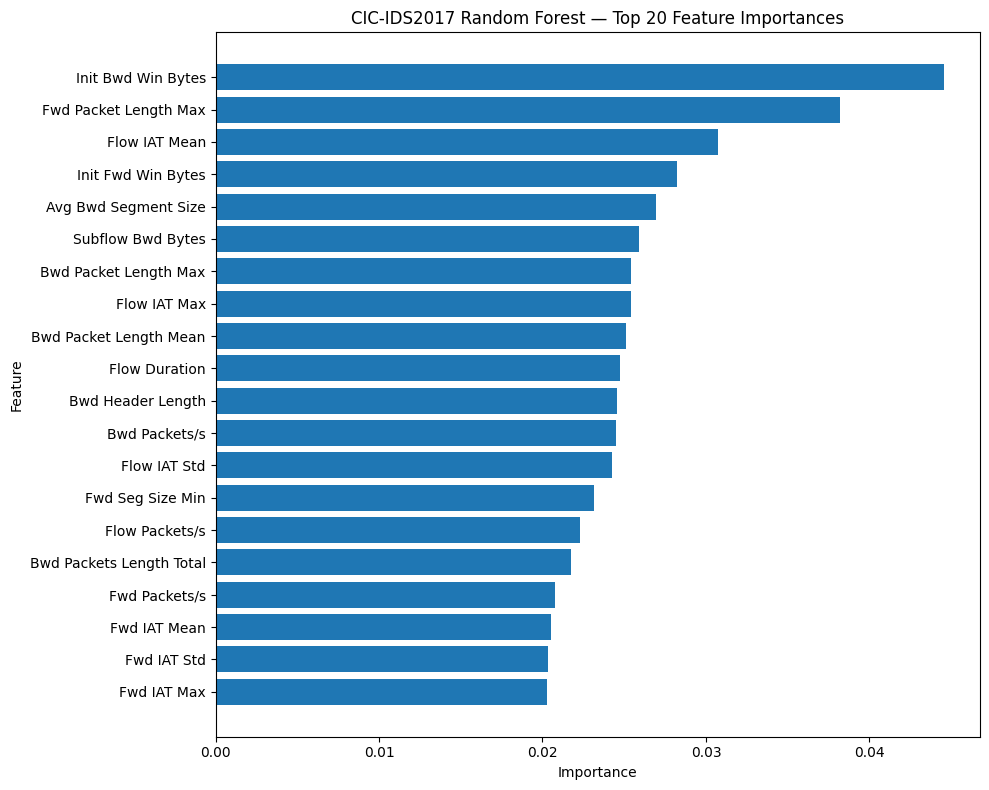

In [ ]:
# Feature importance

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.to_csv(
    ML_OUT / "final_feature_importance.csv",
    index=False
)

display(feature_importance.head(30))

plt.figure(figsize=(10, 8))
top = feature_importance.head(20).sort_values("importance")
plt.barh(top["feature"], top["importance"])
plt.title("CIC-IDS2017 Random Forest — Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(
    ML_OUT / "final_feature_importance_top20.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()
plt.close()

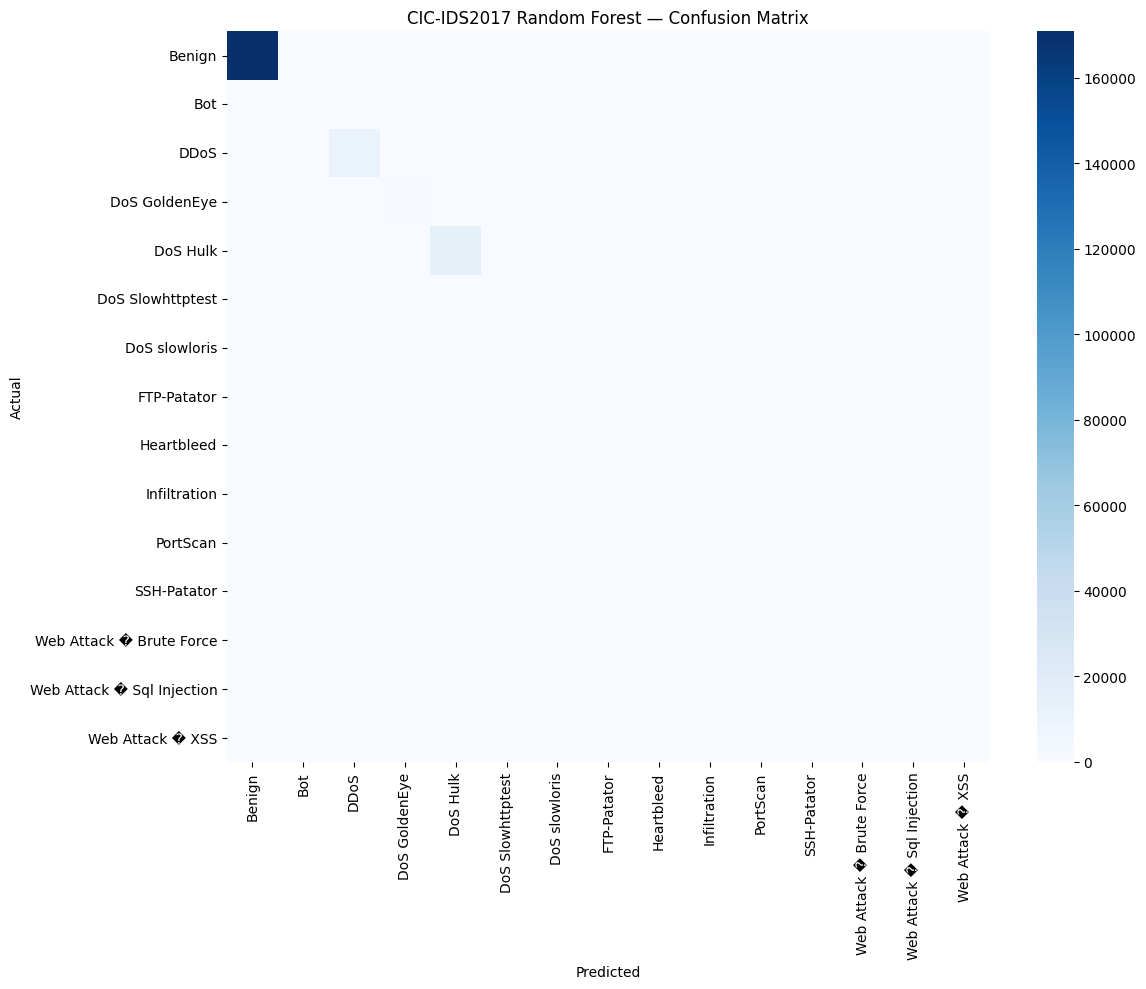

In [ ]:
# Confusion matrix plot

plt.figure(figsize=(12, 10))
sns.heatmap(
    confusion_df,
    annot=False,
    fmt="g",
    cmap="Blues"
)
plt.title("CIC-IDS2017 Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(
    ML_OUT / "final_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [ ]:
# Save ML artifacts

import joblib

joblib.dump(
    rf,
    ML_OUT / "final_random_forest.joblib"
)

joblib.dump(
    medians,
    ML_OUT / "feature_medians.joblib"
)

with open(ML_OUT / "feature_columns.json", "w") as f:
    json.dump(X.columns.tolist(), f, indent=2)

with open(ML_OUT / "constant_features.json", "w") as f:
    json.dump(constant_features, f, indent=2)

print("ML artifacts saved to:", ML_OUT)

ML artifacts saved to: /content/final_cic_project/results/ml


## 19. Dashboard-ready reporting data

The following files are normalized for use in Power BI/Tableau or another reporting layer.

In [ ]:
# Dashboard-ready exports

dashboard_files = {
    "dataset_overview.csv": dataset_overview,
    "dataset_source_inventory.csv": inventory,
    "quality_summary.csv": quality_summary,
    "quality_by_source_file.csv": quality_file,
    "class_distribution.csv": class_summary,
    "class_distribution_by_file.csv": class_file,
    "final_dataset_selection.csv": selection,
    "ml_metrics.csv": metrics,
    "ml_per_class_metrics.csv": per_class,
    "ml_feature_importance.csv": feature_importance,
    "ml_confusion_matrix.csv": confusion_df.reset_index().rename(
        columns={"index": "actual_class"}
    )
}

for filename, frame in dashboard_files.items():
    frame.to_csv(DATASET_RESULTS / filename, index=False)

print("Dashboard-ready files:")
for p in sorted(DATASET_RESULTS.glob("*.csv")):
    print(" -", p.name)

Dashboard-ready files:
 - class_distribution.csv
 - class_distribution_by_file.csv
 - dataset_overview.csv
 - dataset_source_inventory.csv
 - final_dataset_selection.csv
 - ml_confusion_matrix.csv
 - ml_feature_importance.csv
 - ml_metrics.csv
 - ml_per_class_metrics.csv
 - quality_by_source_file.csv
 - quality_summary.csv


In [ ]:
# Final project report

report_path = OUT / "FINAL_PROJECT_REPORT.txt"

with open(report_path, "w", encoding="utf-8") as f:
    f.write("CIC DATASET ANALYSIS — FINAL PROJECT REPORT\n")
    f.write("=" * 60 + "\n\n")

    f.write("DATASET DECISION\n")
    f.write("-" * 60 + "\n")
    for _, r in selection.iterrows():
        f.write(
            f"{r['dataset']}: {r['role']} — {r['decision']}\n"
            f"Reason: {r['reason']}\n\n"
        )

    f.write("SOURCE OVERVIEW\n")
    f.write("-" * 60 + "\n")
    f.write(dataset_overview.to_string(index=False))
    f.write("\n\n")

    f.write("DATA QUALITY\n")
    f.write("-" * 60 + "\n")
    f.write(quality_summary.to_string(index=False))
    f.write("\n\n")

    f.write("FINAL RANDOM FOREST BASELINE\n")
    f.write("-" * 60 + "\n")
    f.write(metrics.to_string(index=False))
    f.write("\n\n")

    f.write("PER-CLASS METRICS\n")
    f.write("-" * 60 + "\n")
    f.write(per_class.to_string(index=False))
    f.write("\n\n")

    f.write("TOP 20 FEATURE IMPORTANCES\n")
    f.write("-" * 60 + "\n")
    f.write(feature_importance.head(20).to_string(index=False))
    f.write("\n")

print("Report written to:", report_path)

Report written to: /content/final_cic_project/results/FINAL_PROJECT_REPORT.txt


In [ ]:
# Final artifact inventory

all_results = sorted(
    [p for p in OUT.rglob("*") if p.is_file()]
)

artifact_rows = []

for p in all_results:
    artifact_rows.append({
        "relative_path": str(p.relative_to(OUT)),
        "size_mb": round(p.stat().st_size / (1024**2), 4)
    })

artifact_inventory = pd.DataFrame(artifact_rows)
artifact_inventory.to_csv(OUT / "artifact_inventory.csv", index=False)

display(artifact_inventory)
print(f"Total files: {len(artifact_inventory)}")

,relative_path,size_mb
0,FINAL_PROJECT_REPORT.txt,0.0036
1,dashboard_data/cic_ddos2019_class_distribution...,0.0623
2,dashboard_data/cic_ids2017_class_distribution.png,0.0651
3,dashboard_data/cic_ids2018_class_distribution.png,0.0731
4,dashboard_data/class_distribution.csv,0.0023
5,dashboard_data/class_distribution_by_file.csv,0.0045
6,dashboard_data/dataset_overview.csv,0.0002
7,dashboard_data/dataset_source_inventory.csv,0.0020
8,dashboard_data/final_dataset_selection.csv,0.0004
9,dashboard_data/ml_confusion_matrix.csv,0.0009


Total files: 25


In [ ]:
# Package final results

import zipfile

ZIP_PATH = BASE / "CIC-Dataset-Analysis_FINAL_RESULTS.zip"

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zf:

    for p in OUT.rglob("*"):

        if p.is_file():
            zf.write(
                p,
                p.relative_to(OUT)
            )

print("Final ZIP:", ZIP_PATH)
print(
    "Size (MB):",
    round(
        ZIP_PATH.stat().st_size / (1024**2),
        3
    )
)

Final ZIP: /content/final_cic_project/CIC-Dataset-Analysis_FINAL_RESULTS.zip
Size (MB): 11.152


In [ ]:
# Colab download

try:
    from google.colab import files
    files.download(str(ZIP_PATH))
except Exception:
    print("Not running in Colab.")
    print("ZIP available at:", ZIP_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>